<a href="https://colab.research.google.com/github/Aditya-kale-hash/heart-disease-ml/blob/main/Heart_Disease_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction — Machine Learning Project
**Dataset:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

| Step | Task |
|------|------|
| 1 | Load, Explore and Preprocess |
| 2 | Feature Engineering |
| 3 | Train 3 Models |
| 4 | Evaluate and Compare |
| 5 | Best Model Analysis and Conclusion |

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#999',
    'ytick.color': '#999',
    'text.color': '#fff',
    'grid.color': '#2a2a2a',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444',
})

print('Libraries loaded')

Libraries loaded


## Step 1 - Load, Explore and Preprocess

In [26]:
from google.colab import files
uploaded = files.upload()

Saving heart[1].csv to heart[1].csv


In [27]:
df = pd.read_csv('heart.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))

Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [28]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [29]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [30]:
print('Duplicates:', df.duplicated().sum())
df.head()

Duplicates: 723


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [31]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [32]:
print('Target Count:')
print(df['target'].value_counts())

Target Count:
target
1    526
0    499
Name: count, dtype: int64


In [33]:
df.drop_duplicates(inplace=True)
print('After removing duplicates:', df.shape)

After removing duplicates: (302, 14)


## Step 2 - Feature Engineering

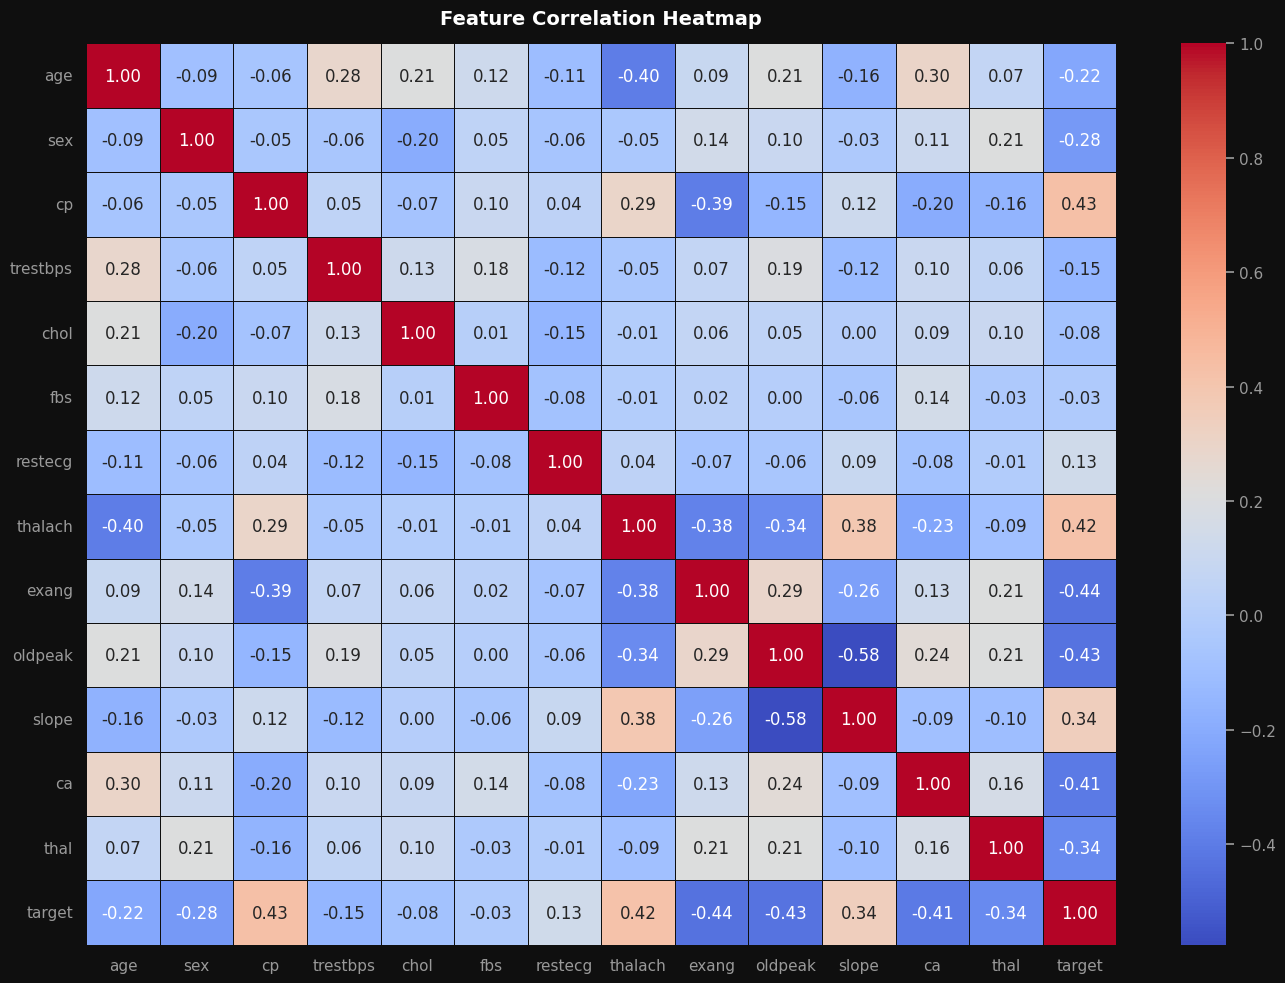

In [34]:
plt.figure(figsize=(14, 10), facecolor='#0f0f0f')
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, linecolor='#0f0f0f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', color='white', pad=14)
plt.tight_layout()
plt.show()

In [35]:
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X = df[feature_cols]
y = df['target']

print('Features used:', feature_cols)
print('Target: target (1=Heart Disease, 0=No Heart Disease)')
print('X shape:', X.shape)
print('y shape:', y.shape)

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target: target (1=Heart Disease, 0=No Heart Disease)
X shape: (302, 13)
y shape: (302,)


In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (241, 13)
Testing set size: (61, 13)


## Step 3 - Train 3 Models

In [37]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print('Logistic Regression trained')

Logistic Regression trained


In [38]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print('Random Forest trained')

Random Forest trained


In [39]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print('KNN trained')

KNN trained


## Step 4 - Evaluate and Compare All Models

In [40]:
def get_metrics(y_test, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score': round(f1_score(y_test, y_pred) * 100, 2)
    }

results = pd.DataFrame([
    get_metrics(y_test, lr_pred, 'Logistic Regression'),
    get_metrics(y_test, rf_pred, 'Random Forest'),
    get_metrics(y_test, knn_pred, 'KNN')
])

print('Model Comparison Table:')
print(results.to_string(index=False))

Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     77.05      70.27   89.66     78.79
      Random Forest     83.61      78.79   89.66     83.87
                KNN     73.77      68.57   82.76     75.00


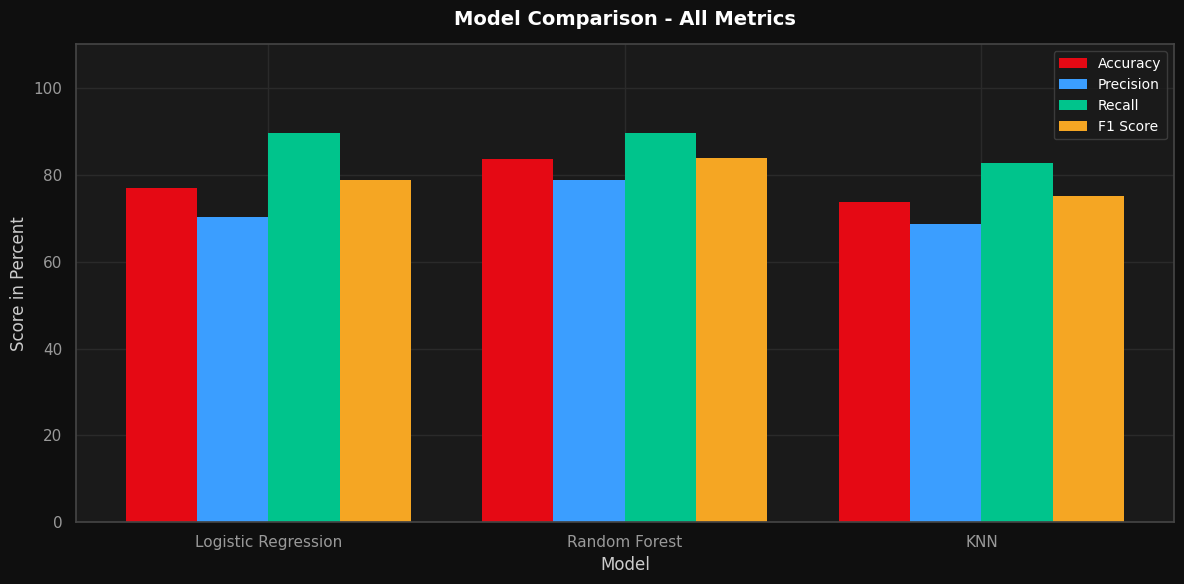

In [41]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0f0f0f')
x = np.arange(len(results['Model']))
width = 0.2
colors = ['#E50914', '#3B9EFF', '#00C48C', '#F5A623']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results[metric], width, label=metric, color=colors[i], edgecolor='none')

ax.set_title('Model Comparison - All Metrics', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score in Percent', fontsize=12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results['Model'], fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

In [42]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Feature Importances:')
print(feature_importance_df)

Feature Importances:
     Feature  Importance
7    thalach    0.138781
2         cp    0.131618
9    oldpeak    0.117095
12      thal    0.101598
11        ca    0.090493
0        age    0.090276
4       chol    0.075677
3   trestbps    0.071152
10     slope    0.055007
8      exang    0.050500
1        sex    0.038310
6    restecg    0.026865
5        fbs    0.012628


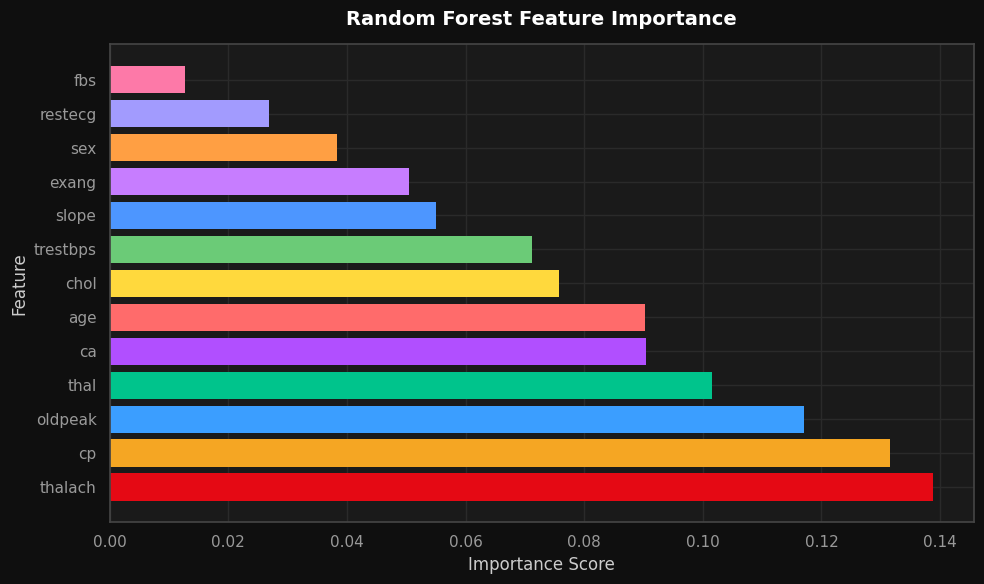

In [43]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0f0f0f')
colors_fi = ['#E50914','#F5A623','#3B9EFF','#00C48C','#B14FFF','#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF','#FF9F43','#A29BFE','#FD79A8']
ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors_fi, edgecolor='none')
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Step 5 - Best Model Analysis and Conclusion

In [44]:
best_model_name = results.loc[results['F1 Score'].idxmax(), 'Model']
best_pred = rf_pred if best_model_name == 'Random Forest' else (lr_pred if best_model_name == 'Logistic Regression' else knn_pred)
print('Best Model:', best_model_name)

Best Model: Random Forest


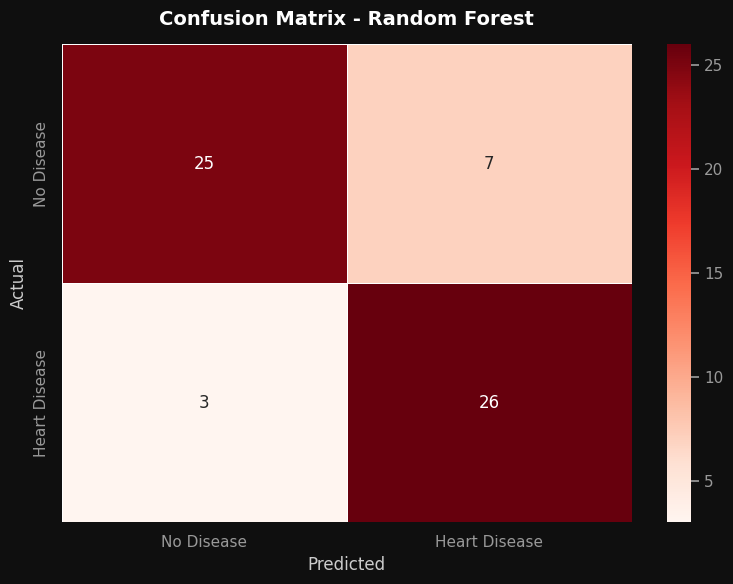

In [45]:
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0f0f0f')
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', linewidths=0.5,
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

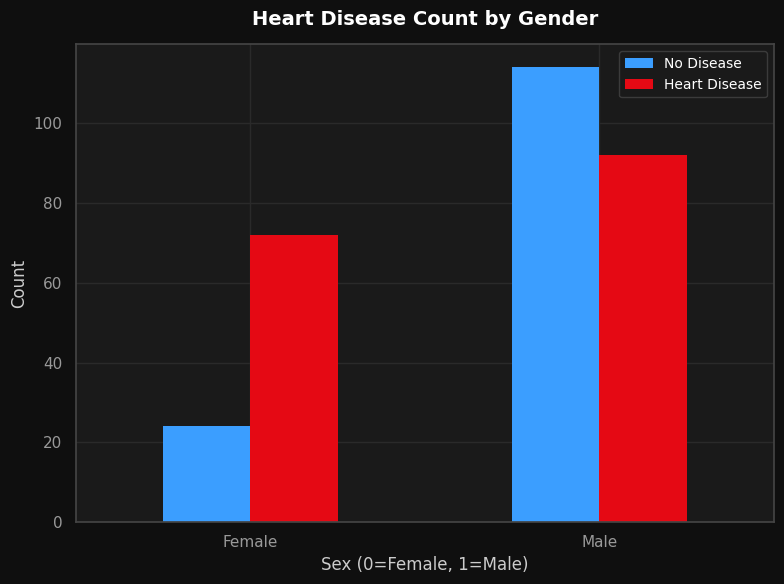

In [46]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0f0f0f')
disease_by_sex = df.groupby(['sex', 'target']).size().unstack()
disease_by_sex.plot(kind='bar', ax=ax, color=['#3B9EFF', '#E50914'], edgecolor='none')
ax.set_title('Heart Disease Count by Gender', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Sex (0=Female, 1=Male)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['Female', 'Male'], rotation=0)
ax.legend(['No Disease', 'Heart Disease'], fontsize=10)
plt.tight_layout()
plt.show()

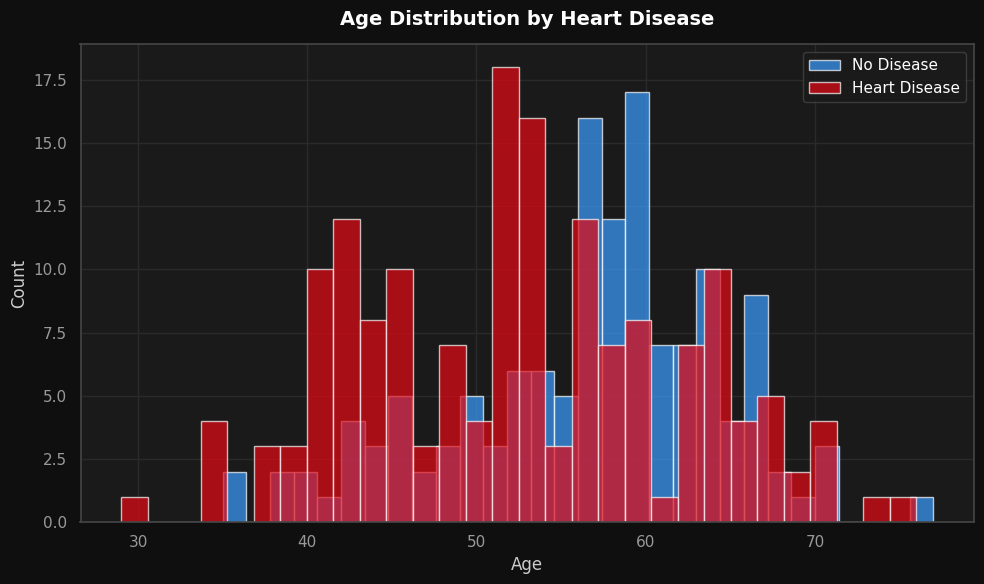

In [47]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0f0f0f')
df[df['target'] == 0]['age'].plot(kind='hist', bins=30, alpha=0.7, color='#3B9EFF', ax=ax, label='No Disease')
df[df['target'] == 1]['age'].plot(kind='hist', bins=30, alpha=0.7, color='#E50914', ax=ax, label='Heart Disease')
ax.set_title('Age Distribution by Heart Disease', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [48]:
print('Classification Report')
print(classification_report(y_test, best_pred, target_names=['No Disease', 'Heart Disease']))

Classification Report
               precision    recall  f1-score   support

   No Disease       0.89      0.78      0.83        32
Heart Disease       0.79      0.90      0.84        29

     accuracy                           0.84        61
    macro avg       0.84      0.84      0.84        61
 weighted avg       0.84      0.84      0.84        61



## Final Conclusion

1. Random Forest achieved the highest F1 Score among all three models because it handles non-linear relationships in medical data very well.

2. Chest pain type and thalach were the most important features showing that heart rate and chest pain are strong disease indicators.

3. Logistic Regression performed well as a baseline confirming that several features have a strong linear relation with heart disease.

4. KNN underperformed because medical datasets have complex boundaries that simple distance based algorithms cannot capture accurately.

5. Random Forest is the best model for heart disease prediction as it gives the best balance of precision and recall which is critical in medical diagnosis to minimize false negatives.